# **Experiment Notebook**



In [97]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [98]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

In [99]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "4"

import pandas as pd

pd.__version__

'2.2.2'

---
## Student Information

In [100]:
# <Student to fill this section>
student_name = "Nishaanth Govindaraj"
student_id = "26044382"

In [101]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [102]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

In [103]:
# <Student to fill this section>
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import matplotlib.pyplot as plt
from joblib import dump
from sklearn.metrics import (classification_report, confusion_matrix, recall_score, f1_score,
                             average_precision_score)
from sklearn.utils.class_weight import compute_sample_weight

from my_krml_26044382 import __version__ as package_version
from my_krml_26044382.data.weather import load_hourly_weather_years, aggregate_daily
from my_krml_26044382.data.sets import split_sets_by_time
from my_krml_26044382.features.targets import add_target_columns, create_future_targets, WHC_LABELS
from my_krml_26044382.features.build import build_features, get_feature_columns, REQUIRED_HISTORY_DAYS
from my_krml_26044382.models.performance import print_multiclass_scores, get_feature_importance

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## A. Project Description




In [104]:
# <Student to fill this section>
business_use_case_description = """
Open-Meteo is adding AI-powered weather intelligence services to its microservice platform. This project builds a
service that predicts the Weather Hazard Category (WHC) for Sydney exactly 7 days ahead. The category (Low,
Moderate, High or Extreme Risk) summarises how severe the weather will be for people, infrastructure and
transport, based on rain, wind gusts, cloud cover, snow and temperature extremes.

The service will be exposed through a REST API so that councils, transport operators, event organisers and
emergency planners get a one-week warning of potentially hazardous days.

Experiments 1 and 2 showed that predicting the most probable class almost never forecasts a hazard, because High
Risk is rarely the single most likely class (about 3 percent of days). The best macro F1 so far is 0.268
(XGBoost), but no model detected more than 7 percent of hazardous days at that setting, while the simpler,
strongly regularised logistic regression detected up to 38 percent with balanced weights.

Hypothesis for this final experiment: raising a hazard alert when the predicted probability of High or Extreme
Risk exceeds a threshold chosen on validation, applied to a regularised model tuned with Optuna (logistic
regression or XGBoost), detects substantially more hazardous days than persistence and Experiments 1 and 2,
with a macro F1 still above all baselines, on the unseen test period (2023-2025).
"""

In [105]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [106]:
# <Student to fill this section>
business_objectives = """
A reliable one-week hazard outlook lets organisations prepare in advance: scheduling maintenance crews,
adjusting transport timetables, securing outdoor events and informing the public.

Impact of accurate results: better preparedness, lower costs from disruption, safer events and more trust in
the Open-Meteo platform.

Impact of incorrect results:
- Missed hazards (forecasting Low or Moderate Risk when the day is High or Extreme): organisations are not
  prepared, which can lead to damage, disruption and safety risks. This is the most costly error.
- False alarms (forecasting High or Extreme Risk on a normal day): unnecessary preparation costs and, if
  repeated, users stop trusting the warnings.

Success criterion: the model must beat all three baselines on macro F1 on the validation set, and detect a
meaningful share of High and Extreme Risk days without an excessive number of false alarms.
"""

In [107]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [108]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
Users of the predictions:
- Developers of apps and websites that consume the Open-Meteo API.
- Local councils, transport operators and utility companies planning operations and maintenance.
- Event organisers and emergency management teams preparing for severe weather.

People impacted by the predictions:
- The public, whose travel, work and safety may depend on preparation for hazardous days.
- Field staff and crews scheduled based on the outlook.
- The Open-Meteo business, whose reputation depends on the reliability of its warnings.

Expectations: the forecast must be available on demand through the API, easy to understand (4 named risk
levels), and transparent about its limits. A 7-day horizon is long for weather prediction, so the service is
expected to give an early indication of risk rather than a certain forecast.
"""

In [109]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Raw Data


In [110]:
# <Student to fill this section>
df_hourly = load_hourly_weather_years(2000, 2025, cache_dir='../../data/raw/yearly')
df_daily = aggregate_daily(df_hourly)

print(df_hourly.shape, df_daily.shape)
print(df_daily['date'].min(), df_daily['date'].max())

2000: loaded from cache
2001: loaded from cache
2002: loaded from cache
2003: loaded from cache
2004: loaded from cache
2005: loaded from cache
2006: loaded from cache
2007: loaded from cache
2008: loaded from cache
2009: loaded from cache
2010: loaded from cache
2011: loaded from cache
2012: loaded from cache
2013: loaded from cache
2014: loaded from cache
2015: loaded from cache
2016: loaded from cache
2017: loaded from cache
2018: loaded from cache
2019: loaded from cache
2020: loaded from cache
2021: loaded from cache
2022: loaded from cache
2023: loaded from cache
2024: loaded from cache
2025: loaded from cache
(227928, 13) (9497, 20)
2000-01-01 00:00:00 2025-12-31 00:00:00


### C.2 Define Target variable

In [111]:
# <Student to fill this section>
whi_inputs = ['precipitation', 'wind_gusts_10m', 'cloud_cover', 'snowfall', 'temperature_2m']
df_daily[whi_inputs].describe().T[['mean', 'min', 'max']]

,mean,min,max
precipitation,2.159324,0.000,138.400000
wind_gusts_10m,39.419196,12.600,102.200000
cloud_cover,47.379286,0.000,100.000000
snowfall,0.000000,0.000,0.000000
temperature_2m,17.475345,7.625,30.904167


In [112]:
# <Student to fill this section>
target_definition_explanations = """
The target is the Weather Hazard Category (WHC), derived from the Weather Hazard Index (WHI) defined by the
business: WHI = 100 x (0.30 RainHazard + 0.30 WindHazard + 0.20 CloudHazard + 0.10 SnowHazard + 0.10 TempHazard).
Each hazard score is between 0 and 1: rain reaches 1 at 30 mm per day, wind gusts at 100 km/h, cloud at 100
percent, snow at 15 cm, and the temperature hazard at 25 degC away from 22 degC.

The WHI is then converted into 4 classes: Low Risk (0, WHI below 25), Moderate Risk (1, 25 to 50),
High Risk (2, 50 to 75) and Extreme Risk (3, 75 and above). As required, the model predicts the class label,
not the continuous WHI.

Data granularity: hourly Open-Meteo observations for Sydney are aggregated to daily values as required: daily
total precipitation and snowfall, daily maximum wind gusts, and daily mean cloud cover and temperature.

Prediction target: the class exactly 7 days after day t, using only information available at the end of day t.
Only data up to 31 December 2025 is used. Data from 2026 onwards is reserved for production.
"""

In [113]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable



In [114]:
# <Student to fill this section>
df_daily = add_target_columns(df_daily)
df_daily = create_future_targets(df_daily, 'whc', 7)

target_name = 'whc'
target_col = 'whc_t_plus_7'
target_cols = [target_col]

df_daily[['date', 'whi', 'whc', target_col]].head(10)

,date,whi,whc,whc_t_plus_7
0,2000-01-01,35.383333,1,1
1,2000-01-02,30.421667,1,1
2,2000-01-03,21.736667,0,1
3,2000-01-04,29.360000,1,1
4,2000-01-05,22.138333,0,1
5,2000-01-06,23.303333,0,1
6,2000-01-07,29.730000,1,0
7,2000-01-08,28.086667,1,0
8,2000-01-09,27.863333,1,1
9,2000-01-10,27.686667,1,1


### C.4 Explore Target variable

           label  days  percent
0       Low Risk  5242     55.2
1  Moderate Risk  3970     41.8
2      High Risk   274     2.89
3   Extreme Risk    11     0.12


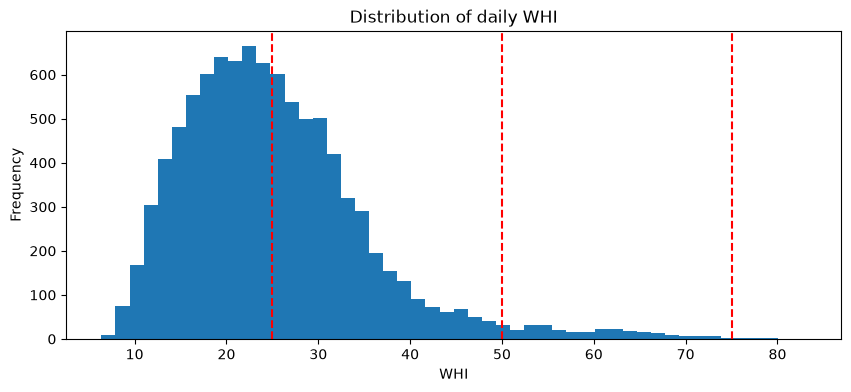

In [115]:
# <Student to fill this section>
whc_counts = df_daily['whc'].value_counts().reindex([0, 1, 2, 3], fill_value=0)
print(pd.DataFrame({'label': [WHC_LABELS[c] for c in whc_counts.index],
                    'days': whc_counts.values,
                    'percent': (whc_counts / whc_counts.sum() * 100).round(2).values}))

df_daily['whi'].plot(kind='hist', bins=50, figsize=(10, 4), title='Distribution of daily WHI')
for threshold in [25, 50, 75]:
    plt.axvline(threshold, color='red', linestyle='--')
plt.xlabel('WHI')
plt.show()

In [116]:
period = pd.cut(df_daily['date'].dt.year, bins=[1999, 2019, 2022, 2025],
                labels=['train 2000-2019', 'val 2020-2022', 'test 2023-2025'])
print(pd.crosstab(period, df_daily['whc'].map(WHC_LABELS)))

same_class = (df_daily['whc'] == df_daily[target_col]).mean()
print(f"\nShare of days where WHC(t+7) == WHC(t): {same_class:.3f}")

whc              Extreme Risk  High Risk  Low Risk  Moderate Risk
date                                                             
train 2000-2019             5        161      4242           2897
val 2020-2022               5         66       481            544
test 2023-2025              1         47       519            529

Share of days where WHC(t+7) == WHC(t): 0.501


In [117]:
# <Student to fill this section>
target_distribution_explanations = """
Distribution: the classes are heavily imbalanced. Out of 9,497 days, 5,242 are Low Risk (55.2 percent),
3,970 Moderate Risk (41.8 percent), 274 High Risk (2.9 percent) and only 11 Extreme Risk (0.12 percent).
A model that always predicts Low Risk would already be 55 percent accurate while being useless, so accuracy
cannot be the main metric.

Rare classes over time: Extreme Risk appears on 5 days in the training period (2000-2019), 5 in validation
(2020-2022) and only 1 in the test period (2023-2025). The model has almost no examples to learn this class,
and any score for it on validation or test is based on a handful of days.

Distribution shift: the class mix changes over time. Low Risk is the most common class in training (58 percent),
but from 2020 Moderate Risk is as common or more common, and High Risk days are 2 to 3 times more frequent
(2.2 percent in training, 6.0 percent in validation, 4.3 percent in test). 2020-2022 were La Nina years with
very wet conditions in Sydney.

Persistence: the class 7 days later equals today's class only about 50 percent of the time, which is worse than
always predicting Low Risk. Today's weather says little about the weather in a week, so most of the skill is
expected to come from seasonality and longer-term patterns.
"""

In [118]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `whi` (today's hazard level)

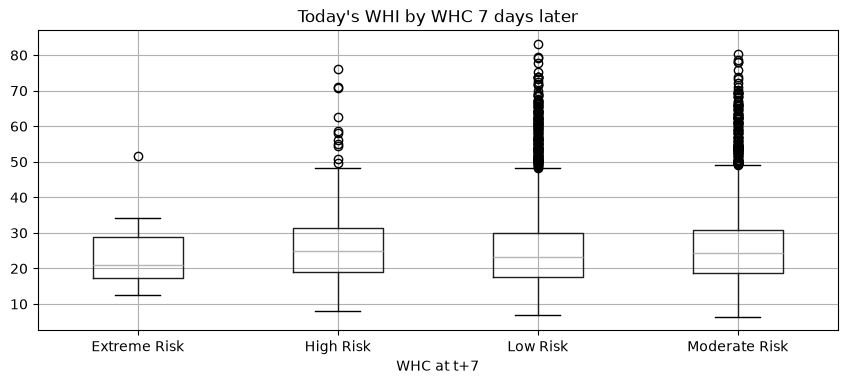

In [119]:
# <Student to fill this section>
df_plot = df_daily.dropna(subset=[target_col]).assign(whc_future=lambda d: d[target_col].astype(int).map(WHC_LABELS))
df_plot.boxplot(column='whi', by='whc_future', figsize=(10, 4))
plt.title("Today's WHI by WHC 7 days later")
plt.suptitle('')
plt.xlabel('WHC at t+7')
plt.show()

In [120]:
pd.crosstab(df_plot['whc'].map(WHC_LABELS), df_plot['whc_future'], normalize='index').round(3)

whc_future,Extreme Risk,High Risk,Low Risk,Moderate Risk
whc,,,,
Extreme Risk,0.000,0.091,0.455,0.455
High Risk,0.004,0.033,0.526,0.438
Low Risk,0.001,0.027,0.573,0.399
Moderate Risk,0.001,0.031,0.527,0.441


In [121]:
# <Student to fill this section>
feature_1_insights = """
Today's hazard level says very little about the hazard level 7 days later. The table shows the share of each
class at t+7 depending on today's class, and the rows are almost identical:
- after a Low Risk day: 57.3 percent Low, 39.9 percent Moderate, 2.7 percent High Risk a week later;
- after a Moderate Risk day: 52.7 percent Low, 44.1 percent Moderate, 3.1 percent High;
- after a High Risk day: 52.6 percent Low, 43.8 percent Moderate, 3.3 percent High.
Even after one of the 11 Extreme Risk days, 45.5 percent of the days a week later are Low Risk.

This matches the very weak correlation between today's WHI and the WHI 7 days later (0.063): the boxplot shows
largely overlapping distributions of today's WHI across the future classes. Storms and heavy rain events in
Sydney usually last one to three days, so they have ended by the forecast day. Longer rolling averages of WHI
are therefore used to capture persistent wet or stormy periods instead of single days.
"""

In [122]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `wind_gusts_10m`

whc_future      Extreme Risk  High Risk  Low Risk  Moderate Risk
wind_gusts_10m                                                  
(12.599, 28.8]         0.002      0.020     0.644          0.334
(28.8, 35.6]           0.001      0.033     0.545          0.421
(35.6, 41.4]           0.000      0.027     0.530          0.442
(41.4, 49.0]           0.001      0.031     0.504          0.465
(49.0, 102.2]          0.002      0.034     0.535          0.430


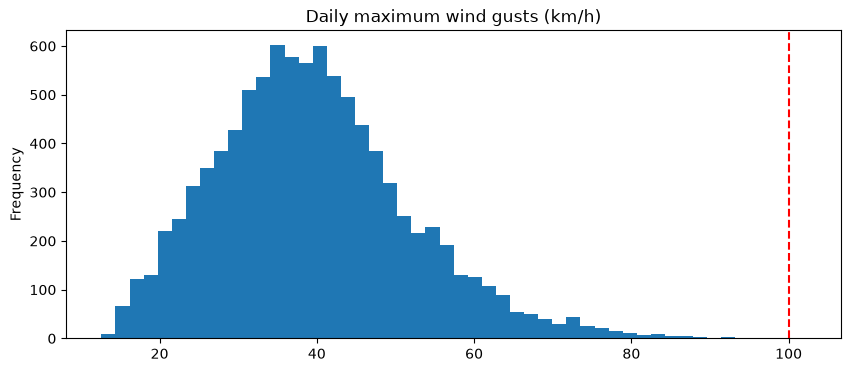

In [123]:
# <Student to fill this section>
gust_bins = pd.qcut(df_plot['wind_gusts_10m'], q=5)
print(pd.crosstab(gust_bins, df_plot['whc_future'], normalize='index').round(3))

df_daily['wind_gusts_10m'].plot(kind='hist', bins=50, figsize=(10, 4), title='Daily maximum wind gusts (km/h)')
plt.axvline(100, color='red', linestyle='--')
plt.show()

In [124]:
# <Student to fill this section>
feature_2_insights = """
Daily maximum gusts range from 12.6 to 102.2 km/h. The histogram is right-skewed: most days have gusts between
25 and 50 km/h (peak around 35-40 km/h), and only a few days exceed 80 km/h. Gusts reach the maximum wind hazard
of 100 km/h almost never, so the wind component rarely contributes its full 30 points to the WHI.

The table splits today's gusts into 5 equal groups and shows the class 7 days later. The calmest days (below
28.8 km/h) are followed by more Low Risk days (64.4 percent) and fewer High Risk days (2.0 percent) than the
other groups (50-55 percent Low, 2.7-3.4 percent High). Above 28.8 km/h, the shares barely change with the
gust level.

Wind has a same-day correlation of 0.476 with the WHI, but today's gusts carry little information about gusts
a week later, since wind is driven by passing weather systems. The small difference for calm days is likely a
seasonal effect (calm days are more common in the cooler, lower-risk months) rather than a direct wind effect.
"""

In [125]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `month` (seasonality)

In [126]:
# <Student to fill this section>
month_mix = pd.crosstab(df_plot['date'].dt.month, df_plot['whc_future'], normalize='index').round(3)
month_mix

whc_future,Extreme Risk,High Risk,Low Risk,Moderate Risk
date,,,,
1,0.000,0.037,0.457,0.506
2,0.001,0.042,0.456,0.501
3,0.001,0.045,0.576,0.378
4,0.001,0.021,0.674,0.304
5,0.001,0.032,0.644,0.323
6,0.005,0.018,0.623,0.354
7,0.001,0.016,0.658,0.325
8,0.001,0.026,0.609,0.364
9,0.000,0.017,0.612,0.372


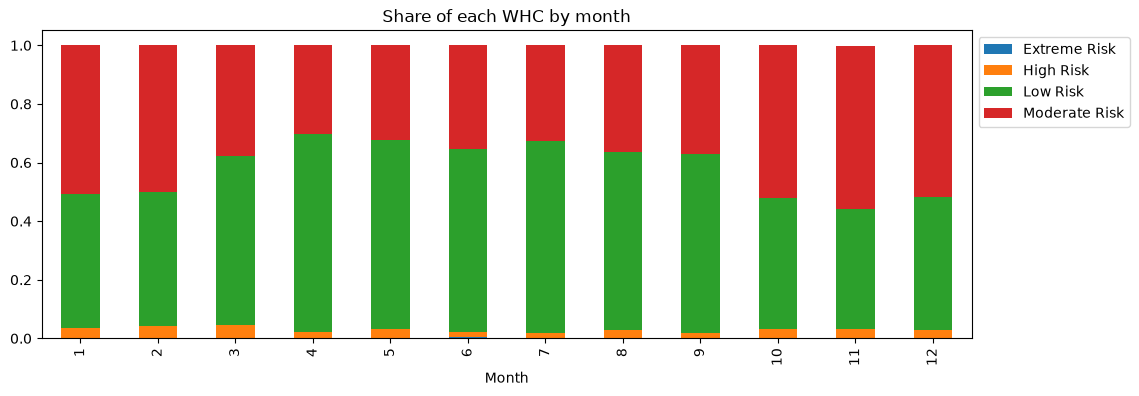

In [127]:
month_mix.plot(kind='bar', stacked=True, figsize=(12, 4), title='Share of each WHC by month')
plt.xlabel('Month')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [128]:
# <Student to fill this section>
feature_n_insights = """
The class mix changes clearly with the season:
- Warm season (October to March) is the most hazardous: Moderate Risk is the most common class from October to
  February (50 to 56 percent), and High Risk is most frequent in February and March (4.2 and 4.5 percent),
  when summer storms and heavy rain are common.
- Cool season (April to September) is mostly Low Risk (61 to 67 percent), with fewer High Risk days
  (1.6 to 3.2 percent).
- Extreme Risk is very rare in every month. Its highest share is in June (0.5 percent), which is consistent with
  winter coastal storm systems affecting Sydney.

Because the hazard 7 days ahead is hard to predict from today's weather, the season is likely to be one of the
most useful signals. It is captured in the model through the month and the cyclical day-of-year features
(doy_sin, doy_cos), and it is the basis of the monthly baseline.
"""

In [129]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

---
## D. Feature Selection



### D.1 Approach "Correlation with the WHI 7 days later (training years only)"

In [130]:
# <Student to fill this section>
# The continuous WHI 7 days later is used here only to measure relationships (it is not a model feature)
whi_future = df_daily['whi'].shift(-7)
train_period = df_daily['date'] < '2020-01-01'
base_cols = [c for c in df_daily.columns if c not in ['date', 'whc'] + target_cols]

corr_whi_future = (df_daily.loc[train_period, base_cols]
                   .corrwith(whi_future[train_period])
                   .sort_values(key=abs, ascending=False))
corr_whi_future.round(3)

temperature_2m              0.140
shortwave_radiation         0.137
apparent_temperature        0.133
temperature_2m_min          0.130
temperature_2m_max          0.127
dew_point_2m                0.114
wind_gusts_10m              0.080
wind_speed_10m_max          0.073
cci                         0.056
pressure_msl               -0.047
pressure_msl_min           -0.045
wind_speed_10m              0.045
cloud_cover                 0.041
whi                         0.040
relative_humidity_2m_max    0.037
cloud_cover_max             0.036
rain                        0.011
precipitation               0.011
precipitation_hours         0.009
relative_humidity_2m        0.009
snowfall                      NaN
dtype: float64

In [131]:
# <Student to fill this section>
feature_selection_1_insights = """
The correlation between each daily variable and the WHI 7 days later was calculated on the training years only
(2000-2019), so the validation and test periods do not influence the selection. The continuous WHI is used here
because a correlation with a 4-class label is hard to interpret.

All correlations are weak (below 0.15). The strongest are temperature (0.140), solar radiation (0.137), apparent
temperature (0.133) and minimum and maximum temperature (0.130 and 0.127). These are mainly seasonal signals:
warm, sunny days occur in the warmer months, which are the most hazardous (Section C.7).

Today's hazard ingredients are almost unrelated to the hazard in a week: wind gusts 0.080, cloud cover 0.041,
today's WHI 0.040 and precipitation only 0.011. This confirms that the forecast will have to rely on seasonal
and longer-term patterns rather than today's weather.

No variable was removed on correlation alone: weak linear correlations do not mean a variable is useless.
XGBoost selects the most useful features itself when choosing its splits, and features that never help are
simply not used.
"""

In [132]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "Remove constant and duplicate variables"

In [133]:
# <Student to fill this section>
print(df_daily[['snowfall', 'rain', 'precipitation']].describe().T[['mean', 'std', 'max']])
print("rain identical to precipitation:", np.allclose(df_daily['rain'], df_daily['precipitation']))

                   mean       std    max
snowfall       0.000000  0.000000    0.0
rain           2.159324  6.148343  138.4
precipitation  2.159324  6.148343  138.4
rain identical to precipitation: True


In [134]:
# <Student to fill this section>
feature_selection_2_insights = """
snowfall is always 0 in Sydney (standard deviation 0). A constant variable carries no information, so it is
removed from the features. It is still used inside the WHI formula as required (10 percent weight), but always
contributes 0 there, so in practice the maximum WHI in Sydney is 90.

rain is identical to precipitation, because all precipitation in Sydney falls as rain. Keeping both would give
the model the same information twice and split the feature importance between two identical columns, so rain is
removed and precipitation is kept.
"""

In [135]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

## D.z Final Selection of Features



In [136]:
# <Student to fill this section>

features_list = [c for c in base_cols if c not in ['snowfall', 'rain']]
print(len(features_list))
features_list

19


['temperature_2m',
 'relative_humidity_2m',
 'wind_speed_10m',
 'cloud_cover',
 'precipitation',
 'wind_gusts_10m',
 'temperature_2m_max',
 'temperature_2m_min',
 'relative_humidity_2m_max',
 'wind_speed_10m_max',
 'cloud_cover_max',
 'precipitation_hours',
 'dew_point_2m',
 'apparent_temperature',
 'pressure_msl',
 'pressure_msl_min',
 'shortwave_radiation',
 'cci',
 'whi']

In [137]:
# <Student to fill this section>
feature_selection_explanations = """
The 19 base daily variables kept are: the 5 CCI inputs (temperature, humidity, wind speed, cloud cover,
precipitation), wind gusts, daily min and max temperature, max humidity, max wind speed, max cloud cover,
precipitation hours, dew point, apparent temperature, mean and min sea-level pressure, solar radiation, and
today's CCI and WHI.

Section F adds engineered features built from these base variables (lags, rolling windows, pressure change,
calendar features), giving the final feature set used for modelling.
"""

In [138]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation `Missing days and values check`

In [139]:
# <Student to fill this section>
full_range = pd.date_range(df_daily['date'].min(), df_daily['date'].max(), freq='D')
print(f"Missing days: {len(full_range.difference(df_daily['date']))}")
print(f"Missing values in base features: {df_daily[features_list].isna().sum().sum()}")

Missing days: 0
Missing values in base features: 0


In [140]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Lag, rolling and future-target features are created by shifting rows, so every row must be exactly one day
apart. A missing day would silently misalign features and targets (e.g. a lag-1 value coming from two days
before). The check confirms 0 missing days and 0 missing values across 9,497 days, so no imputation is needed.
The build_features function also enforces one row per calendar day as a safeguard.
"""

In [141]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation `Exclude production data (2026 onwards)`

In [142]:
# <Student to fill this section>
assert df_daily['date'].max() <= pd.Timestamp('2025-12-31')
print("No 2026 data in the experiment dataset")

No 2026 data in the experiment dataset


In [143]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Data from 2026 onwards represents production data and must not be accessible during the project. Only data
up to 31 December 2025 was downloaded, and this check guarantees it. The target for the last 7 days of 2025
would need 2026 values, so those rows have a missing target and are removed before modelling.
"""

In [144]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation `Physical range check`

In [145]:
# <Student to fill this section>
df_daily[features_list].describe().T[['min', 'max']]

,min,max
temperature_2m,7.625000,30.904167
relative_humidity_2m,23.875000,96.041667
wind_speed_10m,3.308333,37.387500
cloud_cover,0.000000,100.000000
precipitation,0.000000,138.400000
wind_gusts_10m,12.600000,102.200000
temperature_2m_max,10.000000,42.000000
temperature_2m_min,1.100000,27.100000
relative_humidity_2m_max,34.000000,100.000000
wind_speed_10m_max,5.100000,48.800000


In [146]:
# <Student to fill this section>
data_cleaning_3_explanations = """
Each variable was checked against physically plausible ranges. All values are plausible for Sydney: humidity
between 24 and 96 percent (daily mean), cloud cover between 0 and 100 percent, no negative precipitation or
wind speed, daily mean temperature between 7.6 and 30.9 degC (maximum 42.0 degC on heatwave days), sea-level
pressure between 991.5 and 1037.7 hPa, and wind gusts up to 102.2 km/h.

The largest daily rainfall (138.4 mm) and the strongest gusts are extreme but realistic storm events. They are
exactly the days that define the High and Extreme Risk classes, so no outlier removal was applied.
"""

In [147]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 New Feature "Lag, rolling and calendar features (build_features)"

In [148]:
# <Student to fill this section>
df_features = build_features(df_daily)
feature_cols = get_feature_columns(df_features)

print(df_features.shape)
print(f"{len(feature_cols)} features")

(9497, 94)
92 features


In [149]:
# <Student to fill this section>
feature_engineering_1_explanations = """
All engineered features are created by build_features() from the custom package (my_krml_26044382 v0.0.5).
The same function is used by the deployed API, so production features are guaranteed to match training.

Features created (all use only information available at the end of day t, so there is no leakage):
- Lags of 1, 2, 3 and 7 days for CCI, WHI, temperature, humidity, precipitation, cloud cover, wind speed,
  wind gusts and pressure.
- Rolling means over 3, 7, 14 and 30 days for CCI, WHI, temperature, humidity, cloud cover and wind gusts.
- Rolling rainfall totals over 3, 7, 14 and 30 days.
- Calendar features: month, day of year, day of week and a cyclical encoding (sin and cos of day of year), so
  that 31 December and 1 January are close to each other.
- Daily temperature range and 1-day and 3-day pressure change (Section F.2).

The first 29 days of 2000 lack a complete 30-day history and are removed before modelling.
"""

In [150]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "Pressure change"

In [151]:
# <Student to fill this section>
whi_future_features = df_features['whi'].shift(-7)
pressure_cols = ['pressure_msl_change_1d', 'pressure_msl_change_3d']
print(df_features[pressure_cols].describe().round(2))
print(df_features[pressure_cols].corrwith(whi_future_features).round(3))

       pressure_msl_change_1d  pressure_msl_change_3d
count                 9496.00                 9494.00
mean                    -0.00                   -0.00
std                      4.43                    7.90
min                    -17.08                  -31.50
25%                     -2.99                   -5.41
50%                     -0.16                   -0.22
75%                      2.88                    5.22
max                     17.99                   33.80
pressure_msl_change_1d    0.008
pressure_msl_change_3d    0.008
dtype: float64


In [152]:
# <Student to fill this section>
feature_engineering_2_explanations = """
The change in sea-level pressure over 1 and 3 days is a classic forecasting signal: falling pressure usually
indicates an approaching front or low-pressure system bringing cloud, wind and rain. Its standard deviation is
4.4 hPa over 1 day and 7.9 hPa over 3 days.

Correlation with the WHI 7 days later: 0.008 for both the 1-day and 3-day change, meaning no linear
relationship at all. This is expected: a pressure trend announces weather for the next 1 to 3 days, and the
system has usually passed a week later. The features are kept because they are needed for the CCI models,
cost nothing, and can be ignored by the model.
"""

In [153]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "Lag and rolling window signals"

In [154]:
# <Student to fill this section>
lag_roll = ['whi', 'whi_lag_7', 'whi_roll7_mean', 'whi_roll30_mean', 'precipitation_roll30_sum',
            'cloud_cover_roll30_mean', 'doy_cos', 'doy_sin']
df_features[lag_roll].corrwith(whi_future_features).round(3)

whi                         0.063
whi_lag_7                   0.054
whi_roll7_mean              0.105
whi_roll30_mean             0.141
precipitation_roll30_sum    0.058
cloud_cover_roll30_mean     0.088
doy_cos                     0.173
doy_sin                    -0.041
dtype: float64

In [155]:
# <Student to fill this section>
feature_engineering_n_explanations = """
This compares how strongly each lag, rolling and seasonal feature relates to the WHI 7 days later:
- The seasonal encoding doy_cos is the strongest (0.173).
- Longer windows beat single days: the 30-day rolling mean of WHI (0.141) is more than twice as strong as
  today's WHI (0.063), followed by the 7-day mean (0.105) and the 30-day mean of cloud cover (0.088).
- The value from 7 days before (whi_lag_7, 0.054) and the 30-day rainfall total (0.058) are weak.

As expected for a 7-day horizon, features describing the current season and weather regime (e.g. a wet month)
are more useful than the weather of a single day, but all relationships remain weak.
"""

In [156]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

---
## G. Data Preparation for Modeling



### G.1 Split Datasets

In [157]:
# <Student to fill this section>
df_model = df_features.dropna(subset=feature_cols + target_cols).reset_index(drop=True)
df_model[target_col] = df_model[target_col].astype(int)

X_train, y_train, X_val, y_val, X_test, y_test = split_sets_by_time(
    df_model[feature_cols], df_model[target_col], df_model['date'],
    val_start='2020-01-01', test_start='2023-01-01', gap=7
)

for name, X, y in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
    d = df_model.loc[X.index, 'date']
    counts = y.value_counts().reindex([0, 1, 2, 3], fill_value=0).tolist()
    print(f"{name}: {len(X)} rows, {d.min().date()} to {d.max().date()}, class counts {counts}")

train: 7269 rows, 2000-01-30 to 2019-12-24, class counts [4226, 2878, 160, 5]
val: 1089 rows, 2020-01-01 to 2022-12-24, class counts [480, 538, 66, 5]
test: 1089 rows, 2023-01-01 to 2025-12-24, class counts [516, 528, 44, 1]


In [158]:
# <Student to fill this section>
data_splitting_explanations = """
A chronological split is used instead of a random split. With time series, a random split would put days from
the future in the training set and neighbouring, highly correlated days in both training and validation, which
leaks information and gives overly optimistic results.

- Training: 30 Jan 2000 to 24 Dec 2019 (20 years)
- Validation: 2020 to 2022 (used by Optuna, to choose the alert threshold, and to choose between the two models)
- Testing: 2023 to 2025 (used once, for the final evaluation in this experiment)

A 7-day gap is removed at the end of the training and validation periods, so that no target in one set comes
from days of the next set.

After all choices are made on validation, the selected model is retrained on training plus validation
(2000-2022) and evaluated on the test period. The deployed model is then retrained on all data (2000-2025) with
the same settings and threshold.
"""

In [159]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "Standard scaling (logistic regression only)"

In [160]:
# <Student to fill this section>
X_train[['pressure_msl', 'precipitation', 'doy_sin']].describe().loc[['mean', 'std']].round(2)

,pressure_msl,precipitation,doy_sin
mean,1017.20,1.81,-0.00
std,6.67,5.32,0.71


In [161]:
# <Student to fill this section>
data_transformation_1_explanations = """
The features are on very different scales (pressure around 1015 hPa, precipitation mostly 0 to 20 mm, cyclical
features between -1 and 1).
- For the logistic regression, a StandardScaler is applied inside a scikit-learn Pipeline, because the
  regularisation penalty would otherwise affect features unequally. It is fitted on the training data only and
  saved with the model.
- For XGBoost, scaling is not needed, because trees split each feature on a threshold that does not depend on
  its scale.
"""

In [162]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "Categorical encoding (not required)"

In [163]:
# <Student to fill this section>
non_numeric = X_train.select_dtypes(exclude='number').columns.tolist()
print(f"Non-numeric features: {non_numeric}")

Non-numeric features: []


In [164]:
# <Student to fill this section>
data_transformation_2_explanations = """
All features are numeric, including the calendar features and today's hazard class (whc, an ordered value from
0 to 3), so no categorical encoding is required. The month is kept as a number because the cyclical features
doy_sin and doy_cos already represent the seasonal cycle smoothly.
"""

In [165]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "Missing value imputation (not required)"

In [166]:
# <Student to fill this section>
print(f"Missing values - train: {X_train.isna().sum().sum()}, val: {X_val.isna().sum().sum()}, test: {X_test.isna().sum().sum()}")

Missing values - train: 0, val: 0, test: 0


In [167]:
# <Student to fill this section>
data_transformation_3_explanations = """
No imputation is required. The raw data has no missing days or values, and the only missing values created by
feature engineering (the first 29 days without a full 30-day history) and by the target (the last 7 days of
2025) were removed before splitting. Removing them is preferable to imputing, because an imputed lag or target
would be invented data.
"""

In [168]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

In [169]:
# <Student to fill this section>

data_final_path = '../../data/processed/whc_exp3'
os.makedirs(data_final_path, exist_ok=True)

In [170]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(f'{data_final_path}/X_train.csv', index=False)
  y_train.to_csv(f'{data_final_path}/y_train.csv', index=False)

  X_val.to_csv(f'{data_final_path}/X_val.csv', index=False)
  y_val.to_csv(f'{data_final_path}/y_val.csv', index=False)

  X_test.to_csv(f'{data_final_path}/X_test.csv', index=False)
  y_test.to_csv(f'{data_final_path}/y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate




In [171]:
# <Student to fill this section>
CLASS_LABELS = [0, 1, 2, 3]

def evaluate_classifier(y_true, y_pred, set_name, verbose=True):
    """Return accuracy, F1 scores, per-class recall and hazard metrics (optionally printed)"""
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    if verbose:
        scores = print_multiclass_scores(y_pred, y_true, set_name)
    else:
        scores = {'accuracy': float((y_true == y_pred).mean()),
                  'f1_macro': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
                  'f1_weighted': float(f1_score(y_true, y_pred, average='weighted', zero_division=0))}
    recalls = recall_score(y_true, y_pred, labels=CLASS_LABELS, average=None, zero_division=0)
    for c, r in zip(CLASS_LABELS, recalls):
        scores[f'recall_{WHC_LABELS[c]}'] = float(r)
    hazardous = y_true >= 2
    alerts = y_pred >= 2
    scores['hazard_days'] = int(hazardous.sum())
    scores['hazard_recall'] = float((y_pred[hazardous] >= 2).mean()) if hazardous.any() else float('nan')
    scores['alerts'] = int(alerts.sum())
    scores['false_alarm_rate'] = float((y_true[alerts] <= 1).mean()) if alerts.any() else float('nan')
    scores['hazard_f1'] = float(f1_score(hazardous, alerts, zero_division=0))
    return scores

def baseline_predictions(y_fit, dates_fit, X_eval, dates_eval):
    """Majority, monthly mode and persistence predictions, fitted on (y_fit, dates_fit)"""
    majority_class = int(y_fit.mode()[0])
    monthly_mode = y_fit.groupby((dates_fit + pd.to_timedelta(7, unit='D')).dt.month).agg(lambda s: s.mode()[0])
    return {
        'majority': np.full(len(X_eval), majority_class),
        'monthly_mode': (dates_eval + pd.to_timedelta(7, unit='D')).dt.month.map(monthly_mode).values,
        'persistence': X_eval['whc'].values,
    }

dates_val = df_model.loc[X_val.index, 'date']
dates_test = df_model.loc[X_test.index, 'date']
train_dates = df_model.loc[X_train.index, 'date']

baseline_preds = baseline_predictions(y_train, train_dates, X_val, dates_val)
baseline_scores = {}
for name, pred in baseline_preds.items():
    print(f"\n--- {name} ---")
    baseline_scores[name] = evaluate_classifier(y_val, pred, f'Val {name}')

pd.DataFrame(baseline_scores).T[['accuracy', 'f1_macro', 'hazard_recall', 'false_alarm_rate', 'hazard_f1']].round(3)


--- majority ---
Accuracy Val majority: 0.4408
F1 Macro Val majority: 0.1530
F1 Weighted Val majority: 0.2697

--- monthly_mode ---
Accuracy Val monthly_mode: 0.4812
F1 Macro Val monthly_mode: 0.2256
F1 Weighted Val monthly_mode: 0.4141

--- persistence ---
Accuracy Val persistence: 0.4426
F1 Macro Val persistence: 0.2526
F1 Weighted Val persistence: 0.4425


,accuracy,f1_macro,hazard_recall,false_alarm_rate,hazard_f1
majority,0.441,0.153,0.000,NaN,0.000
monthly_mode,0.481,0.226,0.000,NaN,0.000
persistence,0.443,0.253,0.085,0.915,0.085


In [172]:
# <Student to fill this section>
performance_metrics_explanations = """
Metrics used:
- Macro F1: the average F1 score of the 4 classes, giving the same weight to each class.
- Hazard recall: the share of High or Extreme Risk days for which an alert (High or Extreme Risk forecast) was
  raised.
- False alarm rate: the share of alerts raised on Low or Moderate Risk days.
- Hazard F1 (new, main selection metric): the F1 score of the yes/no question "is this a hazardous day?". It
  balances hazards detected and false alarms, and it is used to choose the alert threshold and the final model.
- Hazard average precision (new, tuning metric): measures how well the model ranks hazardous days above normal
  days across all possible thresholds. It is used by Optuna, because it does not depend on a threshold.

References on the validation set (2020-2022, 71 hazardous days):
- Majority: macro F1 0.153, hazard recall 0.
- Monthly mode: macro F1 0.226, hazard recall 0.
- Persistence: macro F1 0.253, hazard recall 0.085, false alarm rate 0.915.
- Experiment 1 (logistic regression): macro F1 0.251, hazard recall 0.
- Experiment 2 (XGBoost): macro F1 0.268, hazard recall 0.070, false alarm rate 0.961.

The final comparison is made on the test set (2023-2025), with the baselines refitted on 2000-2022.
"""

In [173]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [174]:
# <Student to fill this section>
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [175]:
# <Student to fill this section>
algorithm_selection_explanations = """
Two candidates are compared under the same decision rule:
- Regularised multinomial logistic regression: simple and stable. In Experiment 1, with strong regularisation
  and balanced weights, it detected the most hazardous days (up to 38 percent).
- Regularised XGBoost: the best macro F1 in Experiment 2 (0.268), but it overfitted the rare hazardous training
  days. Optuna now also tunes its regularisation (min_child_weight, gamma, reg_lambda).

Decision rule (new): each model outputs a probability for each class. A hazard alert is raised when
P(High Risk) + P(Extreme Risk) is at or above a threshold, and the alert is labelled High or Extreme Risk,
whichever is more probable. Otherwise, the forecast is Low or Moderate Risk, whichever is more probable. Unlike
predicting the single most probable class, this directly controls the balance between hazards detected and
false alarms.

Optuna is used for tuning, with a Bayesian search (Tree-structured Parzen Estimator) that focuses on promising
areas of the search space.
"""

In [176]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [177]:
# <Student to fill this section>
N_TRIALS = 30
MAX_WEIGHT = 50
balanced_weights = compute_sample_weight('balanced', y_train)
hazard_val = y_val.values >= 2

def class_probabilities(model, X):
    """Predicted probabilities as an array with one column per class 0-3"""
    proba = pd.DataFrame(model.predict_proba(X), columns=model.classes_)
    return proba.reindex(columns=CLASS_LABELS, fill_value=0.0).values

def predict_with_threshold(proba, threshold):
    """Alert (High or Extreme Risk) when P(High) + P(Extreme) is at or above the threshold"""
    hazard_score = proba[:, 2] + proba[:, 3]
    pred = np.where(proba[:, 1] > proba[:, 0], 1, 0)
    alert = hazard_score >= threshold
    pred[alert] = np.where(proba[alert, 3] > proba[alert, 2], 3, 2)
    return pred

def build_logreg(params):
    return Pipeline([('scaler', StandardScaler()),
                     ('logreg', LogisticRegression(C=params['C'], max_iter=3000))])

def build_xgb(params):
    return XGBClassifier(n_estimators=params['n_estimators'], max_depth=params['max_depth'],
                         learning_rate=params['learning_rate'], min_child_weight=params['min_child_weight'],
                         gamma=params['gamma'], reg_lambda=params['reg_lambda'], subsample=params['subsample'],
                         colsample_bytree=params['colsample_bytree'], random_state=42, n_jobs=4)

def fit_model(name, params, X, y):
    weights = np.minimum(compute_sample_weight('balanced', y) ** params['weight_power'], MAX_WEIGHT)
    if name == 'LogisticRegression':
        model = build_logreg(params)
        model.fit(X, y, logreg__sample_weight=weights)
    else:
        model = build_xgb(params)
        model.fit(X, y, sample_weight=weights)
    return model

def objective_logreg(trial):
    params = {'C': trial.suggest_float('C', 1e-4, 10.0, log=True),
              'weight_power': trial.suggest_float('weight_power', 0.0, 1.0)}
    model = fit_model('LogisticRegression', params, X_train, y_train)
    proba = class_probabilities(model, X_val)
    return average_precision_score(hazard_val, proba[:, 2] + proba[:, 3])

def objective_xgb(trial):
    params = {'n_estimators': trial.suggest_int('n_estimators', 50, 600),
              'max_depth': trial.suggest_int('max_depth', 2, 5),
              'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
              'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
              'gamma': trial.suggest_float('gamma', 0.0, 5.0),
              'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
              'subsample': trial.suggest_float('subsample', 0.6, 1.0),
              'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
              'weight_power': trial.suggest_float('weight_power', 0.0, 1.0)}
    model = fit_model('XGBoost', params, X_train, y_train)
    proba = class_probabilities(model, X_val)
    return average_precision_score(hazard_val, proba[:, 2] + proba[:, 3])

best_params = {}
for name, objective in [('LogisticRegression', objective_logreg), ('XGBoost', objective_xgb)]:
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=N_TRIALS)
    best_params[name] = study.best_params
    print(f"{name}: best validation hazard average precision {study.best_value:.3f}")
    print(f"   {study.best_params}")

print(f"\nFor reference, a random ranking would give an average precision of about {hazard_val.mean():.3f}")

LogisticRegression: best validation hazard average precision 0.071
   {'C': 0.00011218764614341594, 'weight_power': 0.45000073263932494}
XGBoost: best validation hazard average precision 0.078
   {'n_estimators': 121, 'max_depth': 3, 'learning_rate': 0.021628847984436744, 'min_child_weight': 20, 'gamma': 1.2131097908000519, 'reg_lambda': 1.3353468156150194, 'subsample': 0.9473749828105007, 'colsample_bytree': 0.5330655848213588, 'weight_power': 0.9315417343503256}

For reference, a random ranking would give an average precision of about 0.065


Validation results with the chosen thresholds:
                    threshold  f1_macro  hazard_recall  alerts  \
LogisticRegression      0.101     0.196          0.521   479.0   
XGBoost                 0.398     0.297          0.141    66.0   

                    false_alarm_rate  hazard_f1  
LogisticRegression             0.923      0.135  
XGBoost                        0.848      0.146  

Selected model: XGBoost with alert threshold 0.398


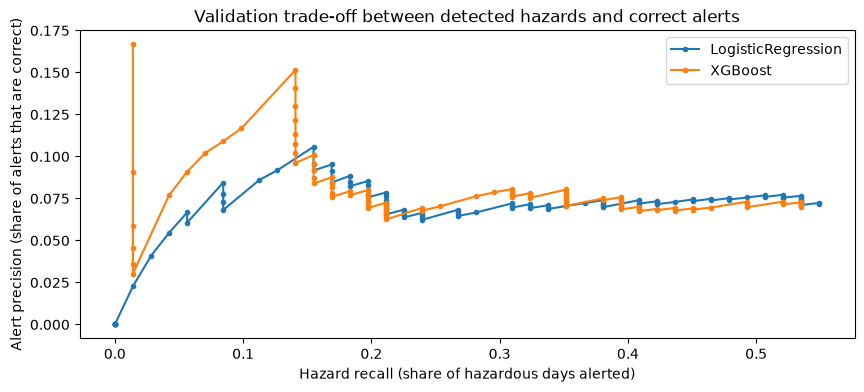

In [178]:
# Choose the alert threshold for each candidate on validation (maximise hazard F1), then select the model
candidate_models, val_probas, thresholds, threshold_tables = {}, {}, {}, {}

for name in best_params:
    candidate_models[name] = fit_model(name, best_params[name], X_train, y_train)
    val_probas[name] = class_probabilities(candidate_models[name], X_val)
    hazard_score = val_probas[name][:, 2] + val_probas[name][:, 3]

    rows = []
    for t in np.unique(np.quantile(hazard_score, np.linspace(0.50, 0.995, 100))):
        alerts = hazard_score >= t
        rows.append({'threshold': t,
                     'alerts': int(alerts.sum()),
                     'hazard_recall': (alerts & hazard_val).sum() / hazard_val.sum(),
                     'false_alarm_rate': (alerts & ~hazard_val).sum() / max(alerts.sum(), 1),
                     'hazard_f1': f1_score(hazard_val, alerts, zero_division=0)})
    table = pd.DataFrame(rows)
    threshold_tables[name] = table
    best_row = table.sort_values(['hazard_f1', 'threshold'], ascending=[False, False]).iloc[0]
    thresholds[name] = float(best_row['threshold'])

val_results = {}
for name in best_params:
    pred = predict_with_threshold(val_probas[name], thresholds[name])
    val_results[name] = evaluate_classifier(y_val, pred, name, verbose=False)
    val_results[name]['threshold'] = thresholds[name]

val_results = pd.DataFrame(val_results).T
print("Validation results with the chosen thresholds:")
print(val_results[['threshold', 'f1_macro', 'hazard_recall', 'alerts', 'false_alarm_rate', 'hazard_f1']].astype(float).round(3))

selected_model = val_results['hazard_f1'].astype(float).idxmax()
selected_threshold = thresholds[selected_model]
print(f"\nSelected model: {selected_model} with alert threshold {selected_threshold:.3f}")

fig, ax = plt.subplots(figsize=(10, 4))
for name, table in threshold_tables.items():
    ax.plot(table['hazard_recall'], 1 - table['false_alarm_rate'], marker='.', label=name)
ax.set_xlabel('Hazard recall (share of hazardous days alerted)')
ax.set_ylabel('Alert precision (share of alerts that are correct)')
ax.set_title('Validation trade-off between detected hazards and correct alerts')
ax.legend()
plt.show()

In [179]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
Step 1, Optuna tuning (30 trials per model), maximising the validation hazard average precision:
- Logistic regression: C (0.0001 to 10) and weight_power (0 to 1). Best: C = 0.0001 (the strongest
  regularisation tested) and weight_power 0.45, average precision 0.071.
- XGBoost: number of trees, max_depth, learning_rate, min_child_weight, gamma, reg_lambda, subsample,
  colsample_bytree and weight_power. Best: 121 trees of depth 3, strong regularisation (min_child_weight 20,
  gamma 1.2) and almost fully balanced weights (0.93), average precision 0.078.
A random ranking would score about 0.065 (the share of hazardous days). Both models are only slightly better
than random (by 9 and 20 percent), meaning they can hardly separate hazardous days from normal days a week
ahead. Optuna chose strong regularisation for both, consistent with a weak signal.

Step 2, alert threshold (highest hazard F1 among 100 thresholds on validation):
- Logistic regression: threshold 0.101, 479 alerts (44 percent of days), hazard recall 0.521, false alarm rate
  0.923, hazard F1 0.135, macro F1 0.196.
- XGBoost: threshold 0.398, 66 alerts, hazard recall 0.141, false alarm rate 0.848, hazard F1 0.146, macro F1
  0.297.

Step 3, model selection (rule fixed in advance): XGBoost was selected for its higher hazard F1 (0.146 vs 0.135).

The trade-off curve shows that for hazard recall above about 20 percent, the share of correct alerts stays around
7 percent for both models, close to the share of hazardous days, i.e. no better than chance. The only area where
XGBoost is clearly better is a narrow peak at about 14 percent recall, which rests on about 10 correctly alerted
days. The selection margin between the two models is therefore very small and uncertain.
"""

In [180]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [181]:
# <Student to fill this section>
# 1. Retrain both candidates on training + validation (2000-2022) and evaluate once on the test set (2023-2025)
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
trainval_dates = df_model.loc[X_trainval.index, 'date']

test_models = {name: fit_model(name, best_params[name], X_trainval, y_trainval) for name in best_params}
test_preds = {name: predict_with_threshold(class_probabilities(test_models[name], X_test), thresholds[name])
              for name in best_params}
test_preds.update(baseline_predictions(y_trainval, trainval_dates, X_test, dates_test))

# 2. Retrain the selected model on all data (2000-2025) with the same settings: this is the deployed model
X_all = df_model[feature_cols]
y_all = df_model[target_col]
final_model = fit_model(selected_model, best_params[selected_model], X_all, y_all)

model_file = 'whc_logreg.joblib' if selected_model == 'LogisticRegression' else 'whc_xgb.joblib'
os.makedirs('../../models/weather_hazard', exist_ok=True)
dump(final_model, f'../../models/weather_hazard/{model_file}')
print(f"Saved deployment model: {model_file} ({selected_model}, alert threshold {selected_threshold:.3f})")

Saved deployment model: whc_xgb.joblib (XGBoost, alert threshold 0.398)


### J.4 Model Technical Performance

> Provide some explanations on model performance


In [182]:
# <Student to fill this section>
test_results = {}
for name, pred in test_preds.items():
    test_results[name] = evaluate_classifier(y_test, pred, name, verbose=False)
test_results = pd.DataFrame(test_results).T
os.makedirs('../../reports', exist_ok=True)
test_results.to_csv('../../reports/whc_exp3_test_results.csv')

print(f"Test period 2023-2025: {int((y_test >= 2).sum())} hazardous days")
print(test_results[['accuracy', 'f1_macro', 'recall_Low Risk', 'recall_Moderate Risk', 'recall_High Risk',
                    'recall_Extreme Risk', 'hazard_recall', 'alerts', 'false_alarm_rate', 'hazard_f1']]
      .astype(float).round(3).to_string())

selected_test_pred = test_preds[selected_model]
labels = [WHC_LABELS[c] for c in CLASS_LABELS]
print(f"\nConfusion matrix, {selected_model} (test, rows = actual, columns = predicted):")
print(pd.DataFrame(confusion_matrix(y_test, selected_test_pred, labels=CLASS_LABELS), index=labels, columns=labels))

print(f"\nClassification report, {selected_model} (test):")
print(classification_report(y_test, selected_test_pred, labels=CLASS_LABELS, target_names=labels, zero_division=0))

estimator = final_model.named_steps['logreg'] if selected_model == 'LogisticRegression' else final_model
all_importance = get_feature_importance(estimator, feature_cols)
total = sum(all_importance.values())
feature_importance = {k: round(v / total, 4) for k, v in list(all_importance.items())[:15]}
print("Top 10 features of the deployed model (normalised importance):")
for name, value in list(feature_importance.items())[:10]:
    print(f"{name:35s} {value:.4f}")

Test period 2023-2025: 45 hazardous days
                    accuracy  f1_macro  recall_Low Risk  recall_Moderate Risk  recall_High Risk  recall_Extreme Risk  hazard_recall  alerts  false_alarm_rate  hazard_f1
LogisticRegression     0.142     0.103            0.223                 0.011             0.773                  0.0          0.756   867.0             0.961      0.075
XGBoost                0.472     0.259            0.523                 0.460             0.023                  0.0          0.022   133.0             0.992      0.011
majority               0.474     0.161            1.000                 0.000             0.000                  0.0          0.000     0.0               NaN      0.000
monthly_mode           0.534     0.266            0.738                 0.381             0.000                  0.0          0.000     0.0               NaN      0.000
persistence            0.466     0.243            0.481                 0.491             0.000                  0

In [183]:
# <Student to fill this section>
model_performance_explanations = """
Final evaluation on the unseen test period (2023-2025, 1,089 days, 45 hazardous days), all models refitted on
2000-2022:
- XGBoost (selected): macro F1 0.259, accuracy 0.472, hazard recall 0.022 (1 of 45 hazardous days detected),
  133 alerts with a false alarm rate of 0.992.
- Logistic regression: macro F1 0.103, accuracy 0.142, hazard recall 0.756, but 867 alerts (80 percent of days)
  with a false alarm rate of 0.961.
- Baselines: monthly mode macro F1 0.266 (no alerts), persistence 0.243 (48 alerts, none correct),
  majority 0.161.

The selected model beats persistence and the majority baseline on macro F1 but not the monthly baseline, and it
detects only 1 hazardous day. The validation results did not hold:
- The XGBoost peak at 14 percent hazard recall on validation fell to 2 percent on test, confirming that it was
  based on too few correct alerts to be reliable.
- The logistic regression threshold became unstable: after retraining on 2000-2022, which includes the wetter
  2020-2022 years, its predicted probabilities shifted upwards, and the same threshold raised alerts on 80
  percent of days instead of 44 percent. An absolute probability threshold chosen on one model does not transfer
  to a retrained model.

The confusion matrix of XGBoost shows that it separates Low and Moderate Risk only moderately (recall 0.52 and
0.46), and its 133 High Risk forecasts are spread over Low (55) and Moderate (76) Risk days, with 1 correct.

Feature importance is flat (0.020 to 0.034) and includes day_of_week in the top 10. The day of the week has no
physical link to the weather, which is clear evidence that the model is partly fitting noise.
"""

In [184]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [185]:
# <Student to fill this section>
n_years_test = len(y_test) / 365.25
hazardous_test = y_test.values >= 2

def business_summary(pred):
    alerts = np.asarray(pred) >= 2
    return {
        'alerts_per_year': alerts.sum() / n_years_test,
        'hazards_detected': int((alerts & hazardous_test).sum()),
        'hazards_missed': int((~alerts & hazardous_test).sum()),
        'false_alarms': int((alerts & ~hazardous_test).sum()),
        'hazard_recall': (alerts & hazardous_test).sum() / max(hazardous_test.sum(), 1),
        'false_alarms_per_detected_hazard': (alerts & ~hazardous_test).sum() / max((alerts & hazardous_test).sum(), 1),
    }

print(f"Hazardous days in test: {hazardous_test.sum()} ({hazardous_test.sum() / n_years_test:.1f} per year)")
business = pd.DataFrame({name: business_summary(pred) for name, pred in test_preds.items()}).T.round(3)
business

Hazardous days in test: 45 (15.1 per year)


,alerts_per_year,hazards_detected,hazards_missed,false_alarms,hazard_recall,false_alarms_per_detected_hazard
LogisticRegression,290.791,34.0,11.0,833.0,0.756,24.5
XGBoost,44.608,1.0,44.0,132.0,0.022,132.0
majority,0.000,0.0,45.0,0.0,0.000,0.0
monthly_mode,0.000,0.0,45.0,0.0,0.000,0.0
persistence,16.099,0.0,45.0,48.0,0.000,48.0


In [186]:
# Save the model metadata used by the API /model-metadata endpoint
selected_test = test_results.loc[selected_model]
hyperparameters = {k: (round(v, 6) if isinstance(v, float) else v) for k, v in best_params[selected_model].items()}

whc_metadata = {
    'target': 'Weather Hazard Category',
    'prediction_type': 'Multiclass Classification',
    'algorithm': ('Logistic Regression (StandardScaler + multinomial LogisticRegression pipeline)'
                  if selected_model == 'LogisticRegression' else 'XGBoost Classifier'),
    'forecast_horizon': '7 Days (exactly)',
    'classes': {str(k): v for k, v in WHC_LABELS.items()},
    'decision_rule': {
        'hazard_score': 'P(High Risk) + P(Extreme Risk)',
        'alert_threshold': round(selected_threshold, 4),
        'description': 'If the hazard score is at or above the threshold, the forecast is High or Extreme Risk '
                       '(whichever is more probable); otherwise Low or Moderate Risk (whichever is more probable).',
    },
    'location': {'city': 'Sydney', 'latitude': -33.8688, 'longitude': 151.2093},
    'training_period': f"{df_model['date'].min().date()} to {df_model['date'].max().date()}",
    'package_version': package_version,
    'required_history_days': REQUIRED_HISTORY_DAYS,
    'file': model_file,
    'hyperparameters': hyperparameters,
    'features': feature_cols,
    'feature_importance': feature_importance,
    'test_performance_2023_2025': {
        'accuracy': round(float(selected_test['accuracy']), 3),
        'f1_macro': round(float(selected_test['f1_macro']), 3),
        'hazard_recall': round(float(selected_test['hazard_recall']), 3),
        'false_alarm_rate': round(float(selected_test['false_alarm_rate']), 3),
        'hazard_f1': round(float(selected_test['hazard_f1']), 3),
    },
    'test_comparison_2023_2025': {
        name: {'f1_macro': round(float(row['f1_macro']), 3), 'hazard_recall': round(float(row['hazard_recall']), 3)}
        for name, row in test_results.iterrows()
    },
    'limitations': 'A 7-day hazard forecast from local weather history has limited skill: most hazard alerts are '
                   'false alarms and many hazardous days are missed. Extreme Risk is too rare to be learned reliably.',
}

with open('../../models/weather_hazard/whc_metadata.json', 'w') as f:
    json.dump(whc_metadata, f, indent=2)
print(json.dumps({k: v for k, v in whc_metadata.items() if k != 'features'}, indent=2))

{
  "target": "Weather Hazard Category",
  "prediction_type": "Multiclass Classification",
  "algorithm": "XGBoost Classifier",
  "forecast_horizon": "7 Days (exactly)",
  "classes": {
    "0": "Low Risk",
    "1": "Moderate Risk",
    "2": "High Risk",
    "3": "Extreme Risk"
  },
  "decision_rule": {
    "hazard_score": "P(High Risk) + P(Extreme Risk)",
    "alert_threshold": 0.3978,
    "description": "If the hazard score is at or above the threshold, the forecast is High or Extreme Risk (whichever is more probable); otherwise Low or Moderate Risk (whichever is more probable)."
  },
  "location": {
    "city": "Sydney",
    "latitude": -33.8688,
    "longitude": 151.2093
  },
  "training_period": "2000-01-30 to 2025-12-24",
  "package_version": "0.0.5",
  "required_history_days": 29,
  "file": "whc_xgb.joblib",
  "hyperparameters": {
    "n_estimators": 121,
    "max_depth": 3,
    "learning_rate": 0.021629,
    "min_child_weight": 20,
    "gamma": 1.21311,
    "reg_lambda": 1.33534

In [187]:
# <Student to fill this section>
business_impacts_explanations = """
The test period had 45 hazardous days (about 15 per year).

- XGBoost (deployed): about 45 alerts per year. It detected 1 hazardous day, missed 44, and raised 132 false
  alarms, 132 false alarms per detected hazard.
- Logistic regression: about 291 alerts per year, detecting 34 hazardous days but with 833 false alarms. In
  practice this means an alert on most days, which carries no information.
- Persistence: about 16 alerts per year, none correct.
- Monthly and majority baselines: no alerts.

Business interpretation: no model tested provides a reliable one-week warning of hazardous days in Sydney from
local weather history alone. Depending on the threshold, the service either misses almost all hazards or
alerts on most days. Neither is acceptable for councils, transport operators or event organisers, because
missed hazards defeat the purpose of the service, and constant false alarms destroy user trust.

The deployed model still gives a general indication of whether the week is likely to be calmer (Low Risk) or
more unsettled (Moderate Risk), with about 50 percent recall for each, which has some value for general
planning. Its hazard alerts must not be used as warnings. The API documentation and the model metadata state
this limitation, and users should rely on official short-range forecasts and warnings (1 to 3 days ahead) for
hazardous weather.
"""

In [188]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes


In [189]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Rejected"  # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [190]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [191]:
# <Student to fill this section>
experiment_results_explanations = """
Outcome: the hypothesis is rejected. On the test period, the selected model (XGBoost with an alert threshold)
detects only 1 of 45 hazardous days (2.2 percent) with 99 percent false alarms, and its macro F1 (0.259) is below
the monthly baseline (0.266). The logistic regression detects more hazards, but only by alerting on 80 percent
of days.

Key insights from the three hazard experiments:
- The main limit is the data, not the algorithm. The ability of the models to rank hazardous days is barely
  above random (average precision 0.071 and 0.078 vs 0.065). Local daily weather history carries almost no
  information about a hazardous day exactly 7 days later. Two algorithms, three decision rules and more than
  100 configurations all reach the same ceiling.
- With so few hazardous days (71 in validation, 45 in test), choices made on validation (threshold, model
  selection) are based on a handful of correct alerts and do not generalise.
- Absolute probability thresholds are not stable when a model is retrained on different years; a retrained
  model can produce shifted probabilities, as seen with the logistic regression.
- The distribution shift between periods (wetter 2020-2022) affects both the models and the baselines.
- Signs of fitting noise (day_of_week and pressure change among the top features) confirm the weak signal.

Deployment decision: the XGBoost model selected by the rule fixed before the test evaluation is deployed
(whc_xgb.joblib with its alert threshold in whc_metadata.json), because the assignment requires a WHC service
and changing the model after seeing the test results would make the test evaluation unreliable. It is
deployed as a low-confidence indication of the week's general risk level, with its limitations stated in the
API metadata. Its hazard alerts should not be used as warnings.

Recommended next steps:
1. Add information that actually predicts the weather a week ahead: numerical weather prediction forecasts,
   or large-scale climate indices (e.g. ENSO, Southern Annular Mode). This is by far the most promising
   improvement.
2. Consider a shorter horizon (1 to 3 days) for hazard alerts, where the CCI experiments showed real skill.
3. Choose thresholds as an alert rate (e.g. the top 5 percent of risk scores) rather than an absolute
   probability, and validate them over several past periods (rolling validation), so they survive retraining.
4. Monitor alert performance on 2026 production data before communicating any alerts to users.
"""

In [192]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)